## 1. Setup do Ambiente

Instalação e verificação das dependências. O `pysus` tem API instável entre versões — inspecionamos o objeto antes de assumir a interface.

In [11]:
pip install pysus

  Using cached aioftp-0.21.4-py3-none-any.whl.metadata (6.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached bigtree-0.12.5-py3-none-any.whl.metadata (28 kB)
  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
  Using cached fastparquet-2024.11.0-cp313-cp313-win_amd64.whl.metadata (4.3 kB)
  Using cached loguru-0.6.0-py3-none-any.whl.metadata (21 kB)
  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Users\Lucas\AppData\Local\Programs\Python\Python313\python.exe C:\Users\Lucas\AppData\Local\Temp\pip-install-s3zbuz5r\numpy_9394184eb86f4adea7a08b7809ea5190\vendored-meson\meson\meson.py setup C:\Users\Lucas\AppData\Local\Temp\pip-install-s3zbuz5r\numpy_9394184eb86f4adea7a08b7809ea5190 C:\Users\Lucas\AppData\Local\Temp\pip-install-s3zbuz5r\numpy_9394184eb86f4adea7a08b7809ea5190\.mesonpy-r26rb0fa -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\Lucas\AppData\Local\Temp\pip-install-s3zbuz5r\numpy_9394184eb86f4adea7a08b7809ea5190\.mesonpy-r26rb0fa\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\Lucas\AppData\Local\Temp\pip-install-s3zbuz5r\numpy_9394184eb86f4adea7a08b7809ea5190
      Build dir: C:\Users\Lucas\AppData\Local\Temp\pip-install-s3z

In [12]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "pysus", "--no-deps", "-q"], check=False)

outros = [
    "sqlalchemy", "pydantic", "dbfread", "blast-dbf",
    "nest_asyncio",                         # fix para event loop do Jupyter
    "pyarrow", "matplotlib", "seaborn", "tqdm",
    "loguru", "aioftp", "anyio", "chardet", "dateparser",
    "bigtree", "duckdb", "duckdb-engine", "fastparquet", "Unidecode",
    "boto3", "httpx", "python-dotenv",
]
for p in outros:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)

print("Instalação concluída.")

Instalação concluída.


In [13]:
import importlib, pysus
print("pysus version:", pysus.__version__)

# Inspeciona a API disponível para entender qual interface usar
print("\nMódulos disponíveis em pysus:")
import pkgutil
for m in pkgutil.iter_modules(pysus.__path__):
    print(" -", m.name)

# Tenta importar os submódulos relevantes
try:
    from pysus.online_data import SIH, CNES
    print("\nInterface pysus.online_data.SIH disponível")
    print("Métodos SIH:", [m for m in dir(SIH) if not m.startswith("_")])
except ImportError as e:
    print("online_data não disponível:", e)

try:
    from pysus.ftp import SIH as SIH2
    print("pysus.ftp.SIH disponível")
except ImportError:
    pass

pysus version: 2.2.0

Módulos disponíveis em pysus:
 - api
 - cli
 - tui
 - utils
online_data não disponível: No module named 'pysus.online_data'


In [14]:
import pandas as pd
import numpy as np
import pyarrow
import matplotlib
import seaborn as sns

print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"pyarrow : {pyarrow.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

pandas  : 2.3.3
numpy   : 2.3.5
pyarrow : 23.0.1
matplotlib: 3.10.8


## 2. Download dos Dados

Download de SIH/RD e CNES/LT para SP, 2022–2023.  
A célula tenta primeiro via `pysus`; se falhar, cai para FTP direto com `urllib`.  
Arquivos `.dbc` são salvos em `dados/raw/` e convertidos para DataFrame.

In [15]:
from pathlib import Path

RAW_DIR = Path("dados/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

ANOS   = [2022, 2023]
MESES  = range(1, 13)
UF     = "SP"

# Mapeia ano -> sufixo de 2 dígitos usado no nome do arquivo
def sufixo_ano(ano):
    return str(ano)[-2:]

# Lista todos os arquivos esperados
arquivos_sih  = [f"RD{UF}{sufixo_ano(a)}{str(m).zfill(2)}.dbc" for a in ANOS for m in MESES]
arquivos_cnes = [f"LT{UF}{sufixo_ano(a)}{str(m).zfill(2)}.dbc" for a in ANOS for m in MESES]

print(f"Arquivos SIH esperados : {len(arquivos_sih)}  — ex: {arquivos_sih[0]}")
print(f"Arquivos CNES esperados: {len(arquivos_cnes)} — ex: {arquivos_cnes[0]}")

Arquivos SIH esperados : 24  — ex: RDSP2201.dbc
Arquivos CNES esperados: 24 — ex: LTSP2201.dbc


In [16]:
import urllib.request
import time

FTP_SIH  = "ftp://ftp.datasus.gov.br/dissemin/publicos/SIHSUS/200801_/Dados/"
FTP_CNES = "ftp://ftp.datasus.gov.br/dissemin/publicos/CNES/200508_/Dados/LT/"

def baixar_ftp(base_url: str, nome_arquivo: str, destino: Path) -> bool:
    """Tenta baixar arquivo do FTP do DATASUS. Retorna True se bem-sucedido."""
    caminho = destino / nome_arquivo
    if caminho.exists():
        return True
    url = base_url + nome_arquivo
    try:
        urllib.request.urlretrieve(url, caminho)
        return True
    except Exception as e:
        print(f"  ERRO {nome_arquivo}: {e}")
        return False

def baixar_via_pysus_sih(arquivo: str, destino: Path) -> bool:
    """Tenta baixar via pysus (adapta à versão instalada)."""
    caminho = destino / arquivo
    if caminho.exists():
        return True
    try:
        # API pysus >= 0.7: usa database objects
        from pysus.ftp.databases.sih import SIH
        db = SIH()
        ano  = int("20" + arquivo[4:6])
        mes  = int(arquivo[6:8])
        files = db.get_files("RD", uf=UF, year=ano, month=mes)
        if files:
            db.download(files, local_dir=str(destino))
            return True
    except Exception:
        pass
    try:
        # API pysus < 0.7: online_data
        from pysus.online_data import SIH
        SIH.download(UF, ano, mes, group="RD", path=str(destino))
        return True
    except Exception:
        pass
    return False

print("Funções de download definidas.")

Funções de download definidas.


In [17]:
# Download SIH/RD — tenta pysus, cai para FTP direto
print("=== Download SIH/RD ===")
sih_ok, sih_fail = [], []
for arq in arquivos_sih:
    ok = baixar_via_pysus_sih(arq, RAW_DIR)
    if not ok:
        ok = baixar_ftp(FTP_SIH, arq, RAW_DIR)
    (sih_ok if ok else sih_fail).append(arq)
    time.sleep(0.3)  # respeita o FTP

print(f"SIH: {len(sih_ok)} OK | {len(sih_fail)} falha")
if sih_fail:
    print("Falhas:", sih_fail[:5])

=== Download SIH/RD ===
SIH: 24 OK | 0 falha


In [18]:
# Download CNES/LT
print("=== Download CNES/LT ===")
cnes_ok, cnes_fail = [], []
for arq in arquivos_cnes:
    ok = baixar_ftp(FTP_CNES, arq, RAW_DIR)
    (cnes_ok if ok else cnes_fail).append(arq)
    time.sleep(0.3)

print(f"CNES LT: {len(cnes_ok)} OK | {len(cnes_fail)} falha")
if cnes_fail:
    print("Falhas:", cnes_fail[:5])

=== Download CNES/LT ===
CNES LT: 24 OK | 0 falha


In [19]:
from pyreaddbc import dbc2dbf
from dbfread import DBF
import tempfile

def dbc_to_df(caminho) -> "pd.DataFrame":
    """
    Lê um arquivo .dbc do DATASUS usando pyreaddbc (extensão C compilada).
    Converte DBC → DBF em arquivo temporário, depois lê com dbfread.
    """
    caminho = Path(caminho)
    dbf_path = caminho.with_suffix(".dbf")
    dbc2dbf(str(caminho), str(dbf_path))
    return pd.DataFrame(iter(DBF(str(dbf_path), encoding="iso-8859-1")))

# ── Teste ──────────────────────────────────────────────────────────────────
print("Testando leitura de RDSP2201.dbc...")
try:
    sih_teste = dbc_to_df(RAW_DIR / f"RD{UF}2201.dbc")
    print(f"OK — shape: {sih_teste.shape}")
    print("Colunas:", list(sih_teste.columns[:10]))
    print(sih_teste.head(3))
except Exception as e:
    import traceback; traceback.print_exc()
    print(f"FALHOU: {e}")

Testando leitura de RDSP2201.dbc...
OK — shape: (199070, 113)
Colunas: ['UF_ZI', 'ANO_CMPT', 'MES_CMPT', 'ESPEC', 'CGC_HOSP', 'N_AIH', 'IDENT', 'CEP', 'MUNIC_RES', 'NASC']
    UF_ZI ANO_CMPT MES_CMPT ESPEC CGC_HOSP          N_AIH IDENT       CEP  \
0  350000     2022       01    02           3521102834194     1  13087546   
1  350000     2022       01    02           3521102834216     1  13085505   
2  350000     2022       01    02           3521102834282     1  13092603   

  MUNIC_RES      NASC  ... DIAGSEC9  TPDISEC1  TPDISEC2  TPDISEC3  TPDISEC4  \
0    350950  19951115  ...                  0         0         0         0   
1    350950  19840104  ...                  0         0         0         0   
2    350950  19980221  ...                  0         0         0         0   

  TPDISEC5  TPDISEC6  TPDISEC7  TPDISEC8  TPDISEC9  
0        0         0         0         0         0  
1        0         0         0         0         0  
2        0         0         0         0   

## 3. Reconhecimento Inicial — SIH/RD

Carrega janeiro/2022 como amostra e inspeciona estrutura, nulos e distribuições das colunas-chave.

In [20]:
# 3a) Shape, dtypes e primeiras linhas
arq_sih_jan22 = RAW_DIR / f"RD{UF}2201.dbc"
sih = dbc_to_df(arq_sih_jan22)

print(f"Shape: {sih.shape}")
print(f"\ndtypes:\n{sih.dtypes.value_counts()}")
sih.head()

Shape: (199070, 113)

dtypes:
object     77
float64    19
int64      17
Name: count, dtype: int64


,UF_ZI,ANO_CMPT,MES_CMPT,ESPEC,CGC_HOSP,N_AIH,IDENT,CEP,MUNIC_RES,NASC,...,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9
0,350000,2022,01,02,,3521102834194,1,13087546,350950,19951115,...,,0,0,0,0,0,0,0,0,0
1,350000,2022,01,02,,3521102834216,1,13085505,350950,19840104,...,,0,0,0,0,0,0,0,0,0
2,350000,2022,01,02,,3521102834282,1,13092603,350950,19980221,...,,0,0,0,0,0,0,0,0,0
3,350000,2022,01,02,,3521102834579,1,13082784,350950,19980907,...,,0,0,0,0,0,0,0,0,0
4,350000,2022,01,02,,3521102834656,1,13067306,350950,20021123,...,,0,0,0,0,0,0,0,0,0


In [21]:
# 3b) % de nulos por coluna
nulos = (sih.isnull().sum() / len(sih) * 100).sort_values(ascending=False)
print("Colunas com nulos (%):\n")
print(nulos[nulos > 0].to_string())

Colunas com nulos (%):

Series([], )


In [22]:
# 3c) Distribuição das colunas-chave
colunas_chave = ["MUNIC_MOV", "ESPEC", "CAR_INT", "COMPLEX", "MORTE"]
for col in colunas_chave:
    if col in sih.columns:
        print(f"\n--- {col} ---")
        print(sih[col].value_counts(dropna=False).head(15))
    else:
        print(f"\n[AVISO] Coluna '{col}' não encontrada — verificar nome real nas colunas do arquivo")


--- MUNIC_MOV ---
MUNIC_MOV
355030    52750
350950     6379
354980     5500
354340     5497
351880     4247
355220     3803
354780     3792
354990     3733
352590     3340
350570     3021
354140     2968
354870     2662
350600     2600
354850     2580
353060     2435
Name: count, dtype: int64

--- ESPEC ---
ESPEC
03    77126
01    57379
02    30671
07    16360
09     8541
05     4903
04     2850
12      405
06      261
87      236
14      115
10       78
08       68
13       54
17       23
Name: count, dtype: int64

--- CAR_INT ---
CAR_INT
02    150407
01     45630
06      2082
05       950
03         1
Name: count, dtype: int64

--- COMPLEX ---
COMPLEX
02    182794
03     16276
Name: count, dtype: int64

--- MORTE ---
MORTE
0    185152
1     13918
Name: count, dtype: int64


In [23]:
# 3d) Estatísticas de QT_DIARIAS — outliers absurdos (>365 dias)
col_dias = "QT_DIARIAS" if "QT_DIARIAS" in sih.columns else None
if col_dias:
    qt = pd.to_numeric(sih[col_dias], errors="coerce")
    print("QT_DIARIAS — estatísticas:")
    print(qt.describe(percentiles=[0.25, 0.75, 0.99]))
    print(f"\nRegistros com QT_DIARIAS > 365: {(qt > 365).sum()}")
    print(f"Registros com QT_DIARIAS = 0  : {(qt == 0).sum()}")
else:
    print("[AVISO] QT_DIARIAS não encontrada. Colunas disponíveis:", list(sih.columns))

QT_DIARIAS — estatísticas:
count    199070.000000
mean          5.001417
std           7.354199
min           0.000000
25%           1.000000
50%           2.000000
75%           5.000000
99%          31.000000
max         305.000000
Name: QT_DIARIAS, dtype: float64

Registros com QT_DIARIAS > 365: 0
Registros com QT_DIARIAS = 0  : 14509


In [24]:
# 3e) Estatísticas de VAL_TOT — zeros e extremos
col_val = "VAL_TOT" if "VAL_TOT" in sih.columns else None
if col_val:
    vt = pd.to_numeric(sih[col_val], errors="coerce")
    print("VAL_TOT — estatísticas:")
    print(vt.describe(percentiles=[0.25, 0.75, 0.99]))
    print(f"\nRegistros com VAL_TOT = 0  : {(vt == 0).sum()}")
    p99 = vt.quantile(0.99)
    print(f"Registros acima do p99 ({p99:.0f}): {(vt > p99).sum()}")
else:
    print("[AVISO] VAL_TOT não encontrada.")

VAL_TOT — estatísticas:
count    199070.000000
mean       1718.609982
std        4509.264043
min           0.000000
25%         381.452500
50%         673.110000
75%        1369.287500
99%       18027.234500
max      229375.350000
Name: VAL_TOT, dtype: float64

Registros com VAL_TOT = 0  : 244
Registros acima do p99 (18027): 1991


In [25]:
# 3f) Contagem de registros por MES_CMPT e ANO_CMPT
for col in ["MES_CMPT", "ANO_CMPT"]:
    if col in sih.columns:
        print(f"\n{col}:\n{sih[col].value_counts().sort_index()}")
    else:
        print(f"[AVISO] {col} não encontrada.")


MES_CMPT:
MES_CMPT
01    199070
Name: count, dtype: int64

ANO_CMPT:
ANO_CMPT
2022    199070
Name: count, dtype: int64


## 4. Reconhecimento Inicial — CNES/LT

In [26]:
# 4a) Shape, dtypes e primeiras linhas
arq_cnes_jan22 = RAW_DIR / f"LT{UF}2201.dbc"
cnes = dbc_to_df(arq_cnes_jan22)

print(f"Shape: {cnes.shape}")
print(f"\ndtypes:\n{cnes.dtypes.value_counts()}")
cnes.head()

Shape: (8578, 28)

dtypes:
object    24
int64      4
Name: count, dtype: int64


,CNES,CODUFMUN,REGSAUDE,MICR_REG,DISTRSAN,DISTRADM,TPGESTAO,PF_PJ,CPF_CNPJ,NIV_DEP,...,NIV_HIER,TERCEIRO,TP_LEITO,CODLEITO,QT_EXIST,QT_CONTR,QT_SUS,QT_NSUS,COMPETEN,NAT_JUR
0,2077647,350010,0209,,,,M,3,53221255006777,1,...,,,1,03,12,0,6,6,202201,3999
1,2077647,350010,0209,,,,M,3,53221255006777,1,...,,,3,75,10,0,8,2,202201,3999
2,2077647,350010,0209,,,,M,3,53221255006777,1,...,,,5,68,1,0,1,0,202201,3999
3,2077647,350010,0209,,,,M,3,53221255006777,1,...,,,3,51,10,0,9,1,202201,3999
4,2077647,350010,0209,,,,M,3,53221255006777,1,...,,,5,45,13,0,7,6,202201,3999


In [27]:
# 4b) Distribuição de TP_LEITO
col_tp = "TP_LEITO" if "TP_LEITO" in cnes.columns else None
if col_tp:
    print("TP_LEITO — contagens:")
    print(cnes[col_tp].value_counts(dropna=False).to_string())
else:
    print("[AVISO] TP_LEITO não encontrada. Colunas:", list(cnes.columns))

TP_LEITO — contagens:
TP_LEITO
1    2291
3    1963
2    1870
5     833
4     818
6     403
7     400


In [28]:
# 4c) Soma de QT_SUS e QT_EXIST por TP_LEITO
for col_q in ["QT_SUS", "QT_EXIST"]:
    if col_q in cnes.columns:
        cnes[col_q] = pd.to_numeric(cnes[col_q], errors="coerce")

if col_tp and "QT_SUS" in cnes.columns:
    resumo = cnes.groupby(col_tp)[["QT_SUS", "QT_EXIST"]].sum().sort_values("QT_SUS", ascending=False)
    print("Capacidade total por tipo de leito:\n")
    print(resumo.to_string())

Capacidade total por tipo de leito:

          QT_SUS  QT_EXIST
TP_LEITO                  
2          20539     35331
1          12564     23874
6          10562     15574
3          10369     22570
4           5469      8971
5           4858      7573
7           1873      3690


In [29]:
# 4d/4e/4f) CNES únicos, regiões e % sem leitos SUS
col_cnes_id = "CNES" if "CNES" in cnes.columns else None
col_reg = "REGSAUDE" if "REGSAUDE" in cnes.columns else None

if col_cnes_id:
    print(f"Estabelecimentos únicos (CNES): {cnes[col_cnes_id].nunique()}")
if col_reg:
    print(f"Regiões de saúde (REGSAUDE)  : {cnes[col_reg].nunique()}")
    print("\nTop regiões por nº de linhas:")
    print(cnes[col_reg].value_counts().head(10))

if "QT_SUS" in cnes.columns:
    pct_zero_sus = (cnes["QT_SUS"] == 0).mean() * 100
    print(f"\n% registros com QT_SUS = 0: {pct_zero_sus:.1f}%")

Estabelecimentos únicos (CNES): 1424
Regiões de saúde (REGSAUDE)  : 76

Top regiões por nº de linhas:
REGSAUDE
        1874
201      853
0101     533
0207     443
216      390
0215     348
0201     321
0209     308
204      289
0217     260
Name: count, dtype: int64

% registros com QT_SUS = 0: 45.1%


## 5. Cálculo do IPH — Versão Simplificada

Carrega todos os meses (2022–2023) mês a mês para evitar estouro de memória, consolida e calcula o IPH em três granularidades.

In [30]:
import calendar
from tqdm.auto import tqdm

def dias_no_mes(ano, mes):
    return calendar.monthrange(ano, mes)[1]

# Carrega e consolida SIH + CNES mês a mês
sih_frames, cnes_frames = [], []

for ano in ANOS:
    for mes in MESES:
        arq_s = RAW_DIR / f"RD{UF}{sufixo_ano(ano)}{str(mes).zfill(2)}.dbc"
        arq_c = RAW_DIR / f"LT{UF}{sufixo_ano(ano)}{str(mes).zfill(2)}.dbc"

        if arq_s.exists():
            df_s = dbc_to_df(arq_s)
            df_s["_ano"] = ano
            df_s["_mes"] = mes
            sih_frames.append(df_s)

        if arq_c.exists():
            df_c = dbc_to_df(arq_c)
            df_c["_ano"] = ano
            df_c["_mes"] = mes
            cnes_frames.append(df_c)

sih_full  = pd.concat(sih_frames,  ignore_index=True) if sih_frames  else pd.DataFrame()
cnes_full = pd.concat(cnes_frames, ignore_index=True) if cnes_frames else pd.DataFrame()

print(f"SIH total : {sih_full.shape}")
print(f"CNES total: {cnes_full.shape}")

SIH total : (5210357, 115)
CNES total: (200075, 30)


In [31]:
# 5a) IPH por hospital (CNES) × mês
# Numerador: contagem de AIH por CNES × competência
col_cnes_sih = "CNES" if "CNES" in sih_full.columns else None

if col_cnes_sih and "QT_SUS" in cnes_full.columns:
    # Denominador: leitos SUS por CNES × competência
    cnes_full["QT_SUS"] = pd.to_numeric(cnes_full["QT_SUS"], errors="coerce").fillna(0)
    cap = (cnes_full.groupby(["CNES", "_ano", "_mes"])["QT_SUS"]
                    .sum()
                    .reset_index()
                    .rename(columns={"QT_SUS": "leitos_sus"}))

    intern = (sih_full.groupby([col_cnes_sih, "_ano", "_mes"])
                      .size()
                      .reset_index(name="internacoes"))
    intern = intern.rename(columns={col_cnes_sih: "CNES"})

    iph_hosp = intern.merge(cap, on=["CNES", "_ano", "_mes"], how="left")
    iph_hosp["dias"] = iph_hosp.apply(lambda r: dias_no_mes(r["_ano"], r["_mes"]), axis=1)
    iph_hosp["denominador"] = iph_hosp["leitos_sus"] * iph_hosp["dias"]
    iph_hosp["iph"] = np.where(
        iph_hosp["denominador"] > 0,
        iph_hosp["internacoes"] / iph_hosp["denominador"],
        np.nan
    )

    def classificar_iph(v):
        if pd.isna(v): return "Sem dados"
        if v < 0.70:   return "Normal"
        if v <= 0.85:  return "Atenção"
        return "Crítico"

    iph_hosp["classe"] = iph_hosp["iph"].map(classificar_iph)
    print(iph_hosp["classe"].value_counts())
    iph_hosp.head()
else:
    print("[AVISO] Colunas CNES ou QT_SUS não encontradas — verifique os nomes reais.")

classe
Normal       14581
Crítico        160
Atenção         79
Sem dados        1
Name: count, dtype: int64


In [32]:
# 5b) IPH por município — IPH ponderado pelos leitos
col_munic = "MUNIC_MOV" if "MUNIC_MOV" in sih_full.columns else None

if col_munic and "iph_hosp" in dir():
    # Linka hospital → município via CNES ST (ou usa MUNIC_MOV do SIH diretamente)
    munic_map = (sih_full.groupby([col_cnes_sih, "_ano", "_mes"])[col_munic]
                          .agg(lambda x: x.mode()[0] if not x.empty else np.nan)
                          .reset_index()
                          .rename(columns={col_cnes_sih: "CNES", col_munic: "municipio"}))

    iph_mun = iph_hosp.merge(munic_map, on=["CNES", "_ano", "_mes"], how="left")
    iph_mun = (iph_mun.dropna(subset=["municipio", "leitos_sus"])
                      .groupby(["municipio", "_ano", "_mes"])
                      .apply(lambda g: np.average(g["iph"].fillna(0),
                                                  weights=g["leitos_sus"].clip(lower=1)),
                             include_groups=False)
                      .reset_index(name="iph_medio"))
    print(iph_mun.shape)
    iph_mun.head()

(7817, 4)


In [33]:
# 5c) IPH por REGSAUDE — ranking das 10 regiões mais críticas por mês
col_reg_cnes = "REGSAUDE" if "REGSAUDE" in cnes_full.columns else None

if col_reg_cnes and "iph_hosp" in dir():
    reg_map = (cnes_full.groupby(["CNES", "_ano", "_mes"])[col_reg_cnes]
                        .agg(lambda x: x.mode()[0] if not x.empty else np.nan)
                        .reset_index())

    iph_reg = iph_hosp.merge(reg_map, on=["CNES", "_ano", "_mes"], how="left")
    iph_reg = (iph_reg.dropna(subset=[col_reg_cnes, "leitos_sus"])
                      .groupby([col_reg_cnes, "_ano", "_mes"])
                      .apply(lambda g: np.average(g["iph"].fillna(0),
                                                  weights=g["leitos_sus"].clip(lower=1)),
                             include_groups=False)
                      .reset_index(name="iph_medio"))

    print("Top 10 regiões mais críticas (IPH médio geral):")
    print(iph_reg.groupby(col_reg_cnes)["iph_medio"]
                 .mean()
                 .sort_values(ascending=False)
                 .head(10)
                 .to_string())

Top 10 regiões mais críticas (IPH médio geral):
REGSAUDE
07      1.230579
101     0.585025
30      0.368515
14      0.235788
105     0.231984
MC      0.189956
0218    0.188172
16      0.182875
207     0.174145
0105    0.161186


## 6. Qualidade dos Dados

In [34]:
problemas = {}

# 6a) MUNIC_MOV inválido — código IBGE SP tem 7 dígitos (prefixo 35)
# SIH usa 6 dígitos (sem o dígito verificador)
if col_munic and col_munic in sih_full.columns:
    munic_vals = sih_full[col_munic].astype(str).str.strip()
    invalidos_munic = munic_vals[~munic_vals.str.match(r"^\d{6}$")]
    problemas["munic_invalido"] = len(invalidos_munic)
    print(f"6a) MUNIC_MOV inválidos: {len(invalidos_munic)} ({len(invalidos_munic)/len(sih_full)*100:.2f}%)")
    print("    Exemplos:", invalidos_munic.value_counts().head(5).to_dict())

# 6b) Hospitais no SIH sem match no CNES LT
if col_cnes_sih and col_cnes_id:
    cnes_ids = set(cnes_full["CNES"].astype(str).unique())
    sih_ids  = set(sih_full[col_cnes_sih].astype(str).unique())
    sem_match = sih_ids - cnes_ids
    problemas["sih_sem_cnes"] = len(sem_match)
    print(f"\n6b) Hospitais no SIH sem match no CNES LT: {len(sem_match)} de {len(sih_ids)}")

# 6c) Meses com volume muito abaixo da média (subnotificação)
vol_mes = sih_full.groupby(["_ano", "_mes"]).size()
media_vol = vol_mes.mean()
baixo_vol = vol_mes[vol_mes < media_vol * 0.5]
problemas["meses_subnotificacao"] = len(baixo_vol)
print(f"\n6c) Meses com volume < 50% da média ({media_vol:.0f}): {len(baixo_vol)}")
if len(baixo_vol):
    print(baixo_vol.to_string())

# 6d) QT_DIARIAS = 0
if "QT_DIARIAS" in sih_full.columns:
    qt_zero = (pd.to_numeric(sih_full["QT_DIARIAS"], errors="coerce") == 0).sum()
    problemas["qt_diarias_zero"] = int(qt_zero)
    print(f"\n6d) QT_DIARIAS = 0: {qt_zero} ({qt_zero/len(sih_full)*100:.2f}%)")

# 6e) VAL_TOT = 0 com MORTE = 1
if "VAL_TOT" in sih_full.columns and "MORTE" in sih_full.columns:
    mask = (pd.to_numeric(sih_full["VAL_TOT"], errors="coerce") == 0) & (sih_full["MORTE"].astype(str) == "1")
    problemas["obito_sem_valor"] = int(mask.sum())
    print(f"\n6e) VAL_TOT=0 com MORTE=1: {mask.sum()} ({mask.sum()/len(sih_full)*100:.2f}%)")

print("\nResumo problemas:", problemas)

6a) MUNIC_MOV inválidos: 0 (0.00%)
    Exemplos: {}

6b) Hospitais no SIH sem match no CNES LT: 0 de 669

6c) Meses com volume < 50% da média (217098): 0

6d) QT_DIARIAS = 0: 400958 (7.70%)

6e) VAL_TOT=0 com MORTE=1: 20 (0.00%)

Resumo problemas: {'munic_invalido': 0, 'sih_sem_cnes': 0, 'meses_subnotificacao': 0, 'qt_diarias_zero': 400958, 'obito_sem_valor': 20}


## 7. Outputs — Salvar Parquets e Relatório

In [35]:
OUT_DIR = Path("dados/processados")
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not sih_full.empty:
    sih_full.to_parquet(OUT_DIR / "sih_sp_2022_2023_raw.parquet", index=False)
    print("Salvo: sih_sp_2022_2023_raw.parquet")

if not cnes_full.empty:
    cnes_full.to_parquet(OUT_DIR / "cnes_lt_sp_2022_2023_raw.parquet", index=False)
    print("Salvo: cnes_lt_sp_2022_2023_raw.parquet")

if "iph_hosp" in dir() and not iph_hosp.empty:
    iph_hosp.to_parquet(OUT_DIR / "iph_por_hospital_mensal.parquet", index=False)
    print("Salvo: iph_por_hospital_mensal.parquet")

if "iph_mun" in dir() and not iph_mun.empty:
    iph_mun.to_parquet(OUT_DIR / "iph_por_municipio_mensal.parquet", index=False)
    print("Salvo: iph_por_municipio_mensal.parquet")

if "iph_reg" in dir() and not iph_reg.empty:
    iph_reg.to_parquet(OUT_DIR / "iph_por_regiao_mensal.parquet", index=False)
    print("Salvo: iph_por_regiao_mensal.parquet")

Salvo: sih_sp_2022_2023_raw.parquet
Salvo: cnes_lt_sp_2022_2023_raw.parquet
Salvo: iph_por_hospital_mensal.parquet
Salvo: iph_por_municipio_mensal.parquet
Salvo: iph_por_regiao_mensal.parquet


In [36]:
from datetime import datetime

relatorio = f"""RELATÓRIO DE QUALIDADE — IPH DATASUS SP 2022–2023
Gerado em: {datetime.now().strftime('%Y-%m-%d %H:%M')}

=== DOWNLOAD ===
SIH/RD baixados : {len(sih_ok)} / 24
CNES/LT baixados: {len(cnes_ok)} / 24
SIH falhas       : {sih_fail if sih_fail else 'nenhuma'}
CNES falhas      : {cnes_fail if cnes_fail else 'nenhuma'}

=== DIMENSÕES ===
SIH total  : {sih_full.shape}
CNES total : {cnes_full.shape}

=== PROBLEMAS IDENTIFICADOS ===
6a) MUNIC_MOV inválidos          : {problemas.get('munic_invalido', 'não verificado')}
6b) Hospitais SIH sem match CNES : {problemas.get('sih_sem_cnes', 'não verificado')}
6c) Meses com subnotificação     : {problemas.get('meses_subnotificacao', 'não verificado')}
6d) QT_DIARIAS = 0               : {problemas.get('qt_diarias_zero', 'não verificado')}
6e) Óbitos sem VAL_TOT           : {problemas.get('obito_sem_valor', 'não verificado')}

=== NOTAS ===
- MUNIC_MOV usa 6 dígitos (SIH) vs 7 dígitos IBGE — ajustar em joins com tabelas externas
- Campos de data vêm como string — converter com pd.to_datetime antes de análises temporais
- Registros com denominador=0 recebem IPH=NaN e classe="Sem dados" (hospital sem leitos SUS registrados no CNES LT)
"""

with open(OUT_DIR / "relatorio_qualidade.txt", "w", encoding="utf-8") as f:
    f.write(relatorio)

print(relatorio)

RELATÓRIO DE QUALIDADE — IPH DATASUS SP 2022–2023
Gerado em: 2026-06-07 18:13

=== DOWNLOAD ===
SIH/RD baixados : 24 / 24
CNES/LT baixados: 24 / 24
SIH falhas       : nenhuma
CNES falhas      : nenhuma

=== DIMENSÕES ===
SIH total  : (5210357, 115)
CNES total : (200075, 30)

=== PROBLEMAS IDENTIFICADOS ===
6a) MUNIC_MOV inválidos          : 0
6b) Hospitais SIH sem match CNES : 0
6c) Meses com subnotificação     : 0
6d) QT_DIARIAS = 0               : 400958
6e) Óbitos sem VAL_TOT           : 20

=== NOTAS ===
- MUNIC_MOV usa 6 dígitos (SIH) vs 7 dígitos IBGE — ajustar em joins com tabelas externas
- Campos de data vêm como string — converter com pd.to_datetime antes de análises temporais
- Registros com denominador=0 recebem IPH=NaN e classe="Sem dados" (hospital sem leitos SUS registrados no CNES LT)



## 8. Visualizações

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

IMG_DIR = Path("figuras")
IMG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

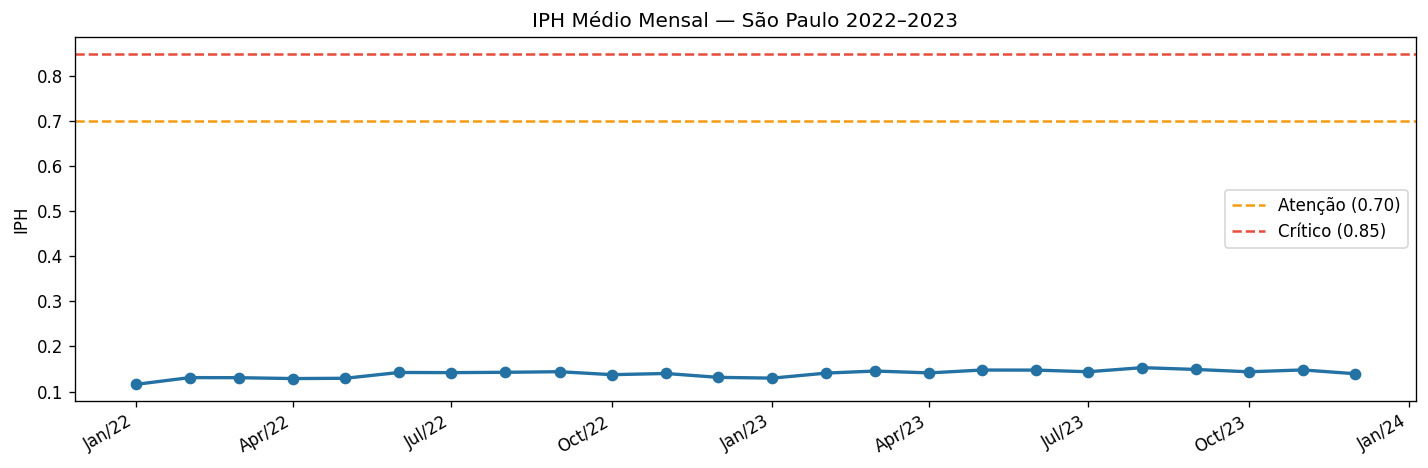

In [38]:
# 8a) Série histórica do IPH médio mensal de SP
if "iph_hosp" in dir() and not iph_hosp.empty:
    serie = (iph_hosp.groupby(["_ano", "_mes"])["iph"]
                     .mean()
                     .reset_index())
    serie["periodo"] = pd.to_datetime(
        serie["_ano"].astype(str) + "-" + serie["_mes"].astype(str).str.zfill(2) + "-01"
    )
    serie = serie.sort_values("periodo")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(serie["periodo"], serie["iph"], marker="o", linewidth=2, color="#2471A3")
    ax.axhline(0.70, color="#F39C12", linestyle="--", label="Atenção (0.70)")
    ax.axhline(0.85, color="#E74C3C", linestyle="--", label="Crítico (0.85)")
    ax.set_title("IPH Médio Mensal — São Paulo 2022–2023")
    ax.set_ylabel("IPH")
    ax.legend()
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b/%y"))
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(IMG_DIR / "01_iph_serie_historica.png")
    plt.show()

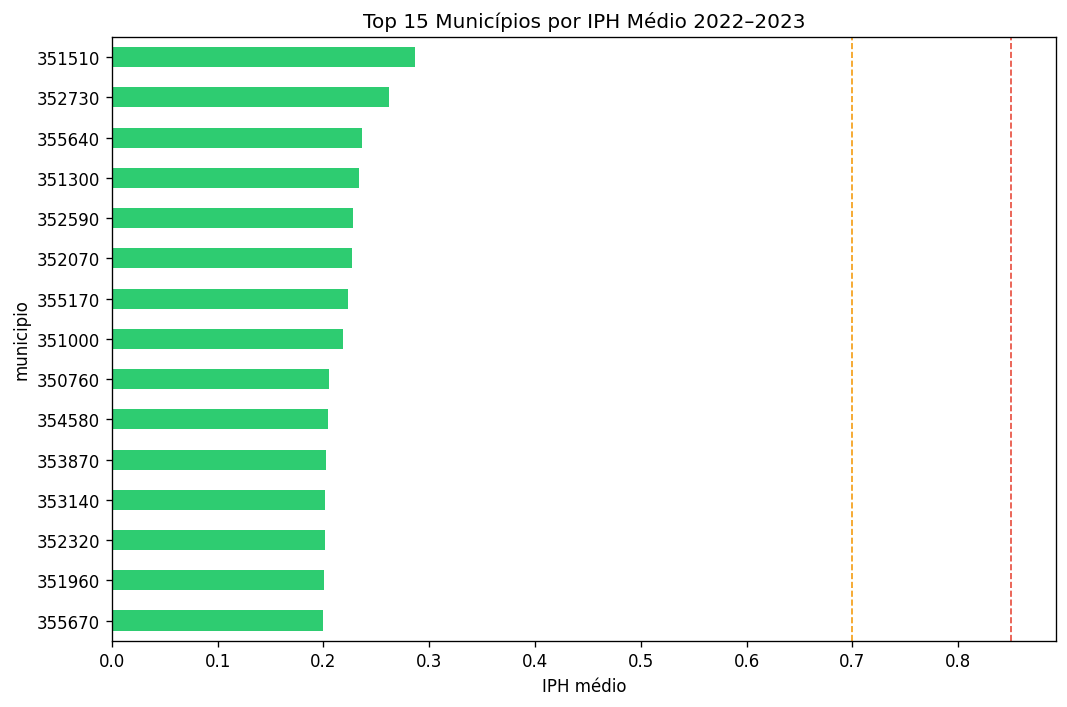

In [39]:
# 8b) Top 15 municípios por IPH médio — barplot horizontal
if "iph_mun" in dir() and not iph_mun.empty:
    top15 = (iph_mun.groupby("municipio")["iph_medio"]
                    .mean()
                    .sort_values(ascending=False)
                    .head(15))

    fig, ax = plt.subplots(figsize=(9, 6))
    cores = ["#E74C3C" if v > 0.85 else "#F39C12" if v > 0.70 else "#2ECC71" for v in top15]
    top15.sort_values().plot(kind="barh", ax=ax, color=cores[::-1])
    ax.axvline(0.70, color="#F39C12", linestyle="--", linewidth=1)
    ax.axvline(0.85, color="#E74C3C", linestyle="--", linewidth=1)
    ax.set_title("Top 15 Municípios por IPH Médio 2022–2023")
    ax.set_xlabel("IPH médio")
    fig.tight_layout()
    fig.savefig(IMG_DIR / "02_top15_municipios_iph.png")
    plt.show()

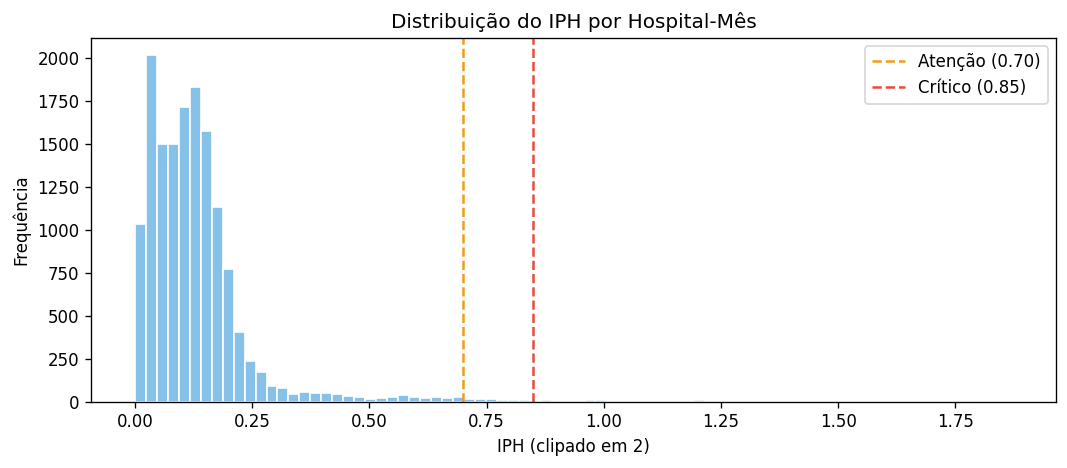

In [40]:
# 8c) Distribuição do IPH — histograma com faixas Normal / Atenção / Crítico
if "iph_hosp" in dir() and not iph_hosp.empty:
    iph_vals = iph_hosp["iph"].dropna()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(iph_vals.clip(upper=2), bins=80, color="#85C1E9", edgecolor="white")
    ax.axvline(0.70, color="#F39C12", linestyle="--", linewidth=1.5, label="Atenção (0.70)")
    ax.axvline(0.85, color="#E74C3C", linestyle="--", linewidth=1.5, label="Crítico (0.85)")
    ax.set_title("Distribuição do IPH por Hospital-Mês")
    ax.set_xlabel("IPH (clipado em 2)")
    ax.set_ylabel("Frequência")
    ax.legend()
    fig.tight_layout()
    fig.savefig(IMG_DIR / "03_distribuicao_iph.png")
    plt.show()

TypeError: Axes.boxplot() got an unexpected keyword argument 'order'. Did you mean 'zorder'?

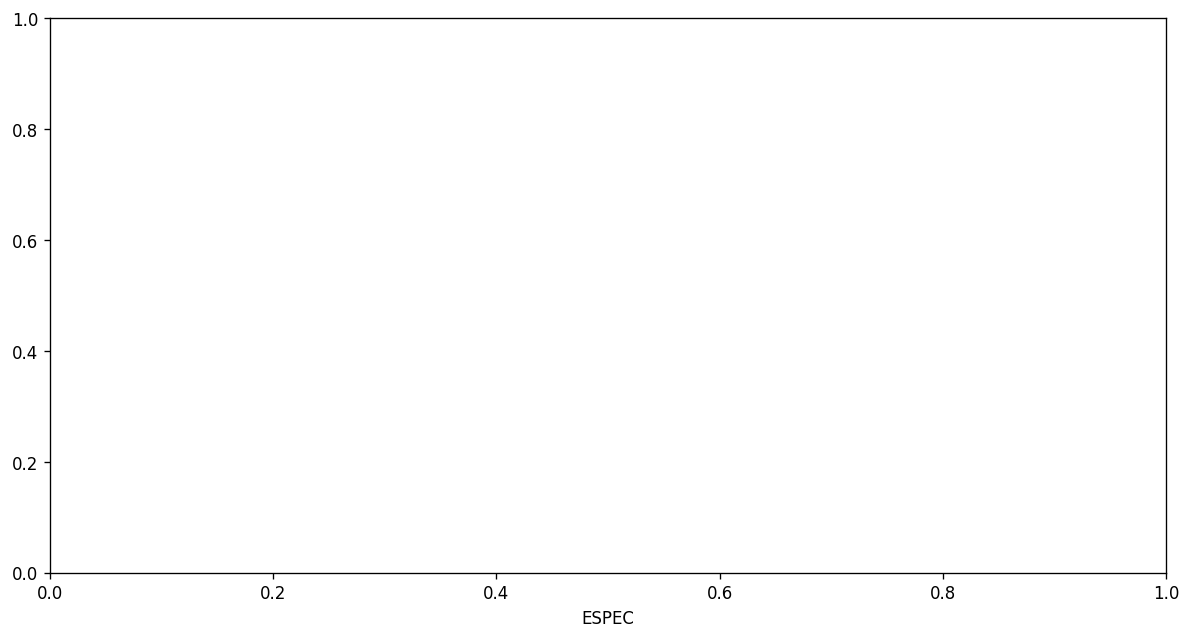

In [41]:
# 8d) Permanência média por especialidade (ESPEC) — boxplot
col_espec = "ESPEC" if "ESPEC" in sih_full.columns else None
col_dias_full = "QT_DIARIAS" if "QT_DIARIAS" in sih_full.columns else None

if col_espec and col_dias_full:
    sih_box = sih_full[[col_espec, col_dias_full]].copy()
    sih_box[col_dias_full] = pd.to_numeric(sih_box[col_dias_full], errors="coerce")
    # Filtra outliers absurdos e pega as top especialidades por volume
    sih_box = sih_box[sih_box[col_dias_full].between(1, 180)]
    top_espec = sih_box[col_espec].value_counts().head(12).index
    sih_box = sih_box[sih_box[col_espec].isin(top_espec)]

    ordem = (sih_box.groupby(col_espec)[col_dias_full]
                    .median()
                    .sort_values(ascending=False)
                    .index)

    fig, ax = plt.subplots(figsize=(12, 6))
    sih_box.boxplot(column=col_dias_full, by=col_espec, ax=ax,
                    order=ordem, showfliers=False,
                    medianprops={"color": "red"})
    ax.set_title("Permanência Média por Especialidade (QT_DIARIAS)")
    ax.set_xlabel("Especialidade (ESPEC)")
    ax.set_ylabel("Dias")
    plt.suptitle("")
    fig.tight_layout()
    fig.savefig(IMG_DIR / "04_permanencia_por_especialidade.png")
    plt.show()
else:
    print("[AVISO] ESPEC ou QT_DIARIAS não encontradas para o boxplot.")

# Inspeção Inicial — Dados DATASUS
### Índice de Pressão Hospitalar (IPH) — São Paulo 2022–2023